In [1]:
# STEP 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
# STEP 2: Upload Excel file
from google.colab import files
uploaded = files.upload()

Saving Phishing_Awareness_and_Online_Security_Practices.xlsx to Phishing_Awareness_and_Online_Security_Practices.xlsx


In [3]:
# STEP 3: Load dataset
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

df.head()

,Timestamp,I agree to participate in this study and understand my data will be used for academic purposes only.,Age Group,Gender,Field of Study,Have you heard of phishing before?,Rate your cybersecurity knowledge,Are you aware that AI can generate phishing emails?,How familiar are you with AI-based phishing techniques?,Do you reuse passwords across multiple accounts?,Do you use Two-Factor Authentication (2FA)?,How often do you check URLs before entering personal data?,"You receive the following email:\nSubject: Urgent: Account Verification Required\nDear User,\nWe noticed unusual activity on your account. Please verify your details to avoid temporary suspension.\nClick here: www.bank-secure-verification.com","Have you ever received a video call from someone impersonating a known person (friend, professor, or staff) that you suspected might be AI-generated?",How confident are you in detecting if a video call is AI-generated (deepfake) rather than a real person?,"You receive a message from a known contact (e.g., friend or professor):\n“Hi, I’m in urgent need of help. Can you quickly send me your login details or OTP? I will explain later.”",Have you ever clicked a suspicious link?,Have you shared personal info on an unsecured website?,Preferred way to learn cybersecurity?,"Would you prefer more practical, hands-on cybersecurity training for detecting phishing?"
0,2026-04-23 14:09:59.278,I Agree,24-27,Male,Computer Science / IT,Yes,3,May be,NaN,Yes,Sometimes,Sometimes,Ignore the email,NaN,NaN,Verify the request by contacting the person th...,Yes,Maybe,Online tutorials,NaN
1,2026-04-23 14:43:13.066,I Agree,24-27,Female,Business / Management,Yes,3,May be,NaN,Yes,Sometimes,Never,Ignore the email,NaN,NaN,Verify the request by contacting the person th...,Yes,Maybe,University courses,NaN
2,2026-05-16 01:08:32.903,I Agree,24-27,Male,Computer Science / IT,Yes,3,Yes,Slightly Familiar,Yes,Sometimes,Occasionally,Contact the official service provider through ...,Yes,Neutral,Verify the request by contacting the person th...,Yes,Maybe,University courses,Yes
3,2026-05-16 01:48:15.944,I Agree,24-27,Male,Engineering / Medical,Yes,5,Yes,Extremely Familiar,No,Always,Always,Check the sender’s email address and website U...,No,Very Confident,Report the message as suspicious,No,No,Social media,Yes
4,2026-05-16 01:49:26.064,I Agree,24-27,Female,Business / Management,Yes,3,Yes,Slightly Familiar,Yes,Sometimes,Never,Ignore the email,No,Not Confident,Verify the request by contacting the person th...,Yes,Maybe,Social media,Yes


In [4]:

df = pd.read_excel(file_name)

# Renaming columns based on  Excel headings
df = df.rename(columns={
    'I agree to participate in this study and understand my data will be used for academic purposes only.': 'Consent',
    'Age Group': 'Age_Group',
    'Gender ': 'Gender',
    'Field of Study ': 'Field_of_Study',
    'Have you heard of phishing before? ': 'Heard_Phishing',
    'Rate your cybersecurity knowledge ': 'Cybersecurity_Knowledge',
    'Are you aware that AI can generate phishing emails?': 'Aware_AI_Phishing',
    'How familiar are you with AI-based phishing techniques? ': 'Familiar_AI_Phishing',
    'Do you reuse passwords across multiple accounts?': 'Reuse_Passwords',
    'Do you use Two-Factor Authentication (2FA)?': 'Use_2FA',
    'How often do you check URLs before entering personal data?': 'Check_URLs',
    'You receive the following email:\nSubject: Urgent: Account Verification Required\nDear User,\nWe noticed unusual activity on your account. Please verify your details to avoid temporary suspension.\nClick here: www.bank-secure-verification.com': 'Email_Scenario_Response',
    'Have you ever received a video call from someone impersonating a known person (friend, professor, or staff) that you suspected might be AI-generated?': 'AI_Video_Call_Experience',
    'How confident are you in detecting if a video call is AI-generated (deepfake) rather than a real person?': 'Deepfake_Detection_Confidence',
    'You receive a message from a known contact (e.g., friend or professor):\n“Hi, I’m in urgent need of help. Can you quickly send me your login details or OTP? I will explain later.”': 'OTP_Message_Response',
    'Have you ever clicked a suspicious link?': 'Clicked_Suspicious_Link',
    'Have you shared personal info on an unsecured website?': 'Shared_Info_Unsecured_Website',
    'Preferred way to learn cybersecurity? ': 'Learning_Preference',
    'Would you prefer more practical, hands-on cybersecurity training for detecting phishing? ': 'Hands_On_Training'
})

print(df.shape)
df.head()

(57, 20)


,Timestamp,Consent,Age_Group,Gender,Field_of_Study,Heard_Phishing,Cybersecurity_Knowledge,Aware_AI_Phishing,Familiar_AI_Phishing,Reuse_Passwords,Use_2FA,Check_URLs,Email_Scenario_Response,AI_Video_Call_Experience,Deepfake_Detection_Confidence,OTP_Message_Response,Clicked_Suspicious_Link,Shared_Info_Unsecured_Website,Learning_Preference,Hands_On_Training
0,2026-04-23 14:09:59.278,I Agree,24-27,Male,Computer Science / IT,Yes,3,May be,NaN,Yes,Sometimes,Sometimes,Ignore the email,NaN,NaN,Verify the request by contacting the person th...,Yes,Maybe,Online tutorials,NaN
1,2026-04-23 14:43:13.066,I Agree,24-27,Female,Business / Management,Yes,3,May be,NaN,Yes,Sometimes,Never,Ignore the email,NaN,NaN,Verify the request by contacting the person th...,Yes,Maybe,University courses,NaN
2,2026-05-16 01:08:32.903,I Agree,24-27,Male,Computer Science / IT,Yes,3,Yes,Slightly Familiar,Yes,Sometimes,Occasionally,Contact the official service provider through ...,Yes,Neutral,Verify the request by contacting the person th...,Yes,Maybe,University courses,Yes
3,2026-05-16 01:48:15.944,I Agree,24-27,Male,Engineering / Medical,Yes,5,Yes,Extremely Familiar,No,Always,Always,Check the sender’s email address and website U...,No,Very Confident,Report the message as suspicious,No,No,Social media,Yes
4,2026-05-16 01:49:26.064,I Agree,24-27,Female,Business / Management,Yes,3,Yes,Slightly Familiar,Yes,Sometimes,Never,Ignore the email,No,Not Confident,Verify the request by contacting the person th...,Yes,Maybe,Social media,Yes


In [5]:
print(df["Consent"].value_counts(dropna=False))

Consent
I Agree    57
Name: count, dtype: int64


Age_Group
21-23    18
24-27    17
27+      13
18-20     9
Name: count, dtype: int64


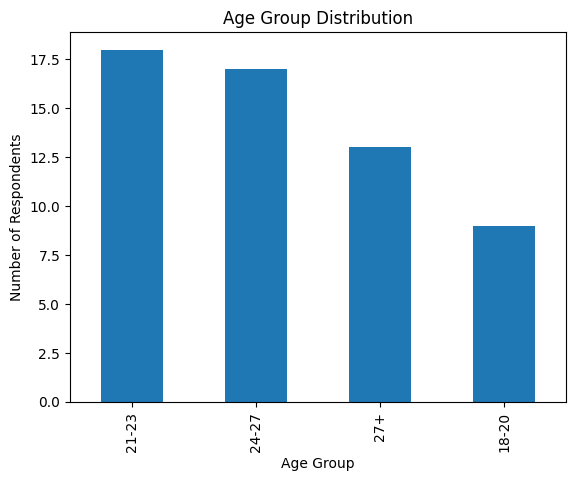

In [6]:
age_counts = df["Age_Group"].dropna().value_counts()

print(age_counts)

age_counts.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")
plt.show()

Gender
Male      30
Female    27
Name: count, dtype: int64


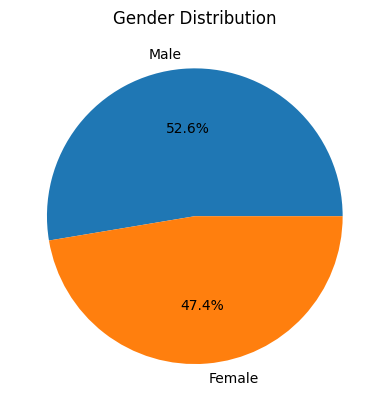

In [7]:
gender_counts = df["Gender"].value_counts()
print(gender_counts)

gender_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

Field_of_Study
Computer Science / IT    23
Business / Management    20
Engineering / Medical    13
Special education         1
Name: count, dtype: int64


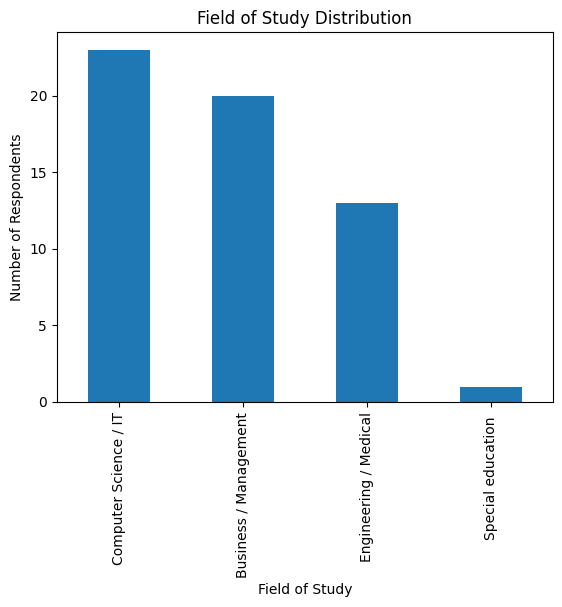

In [8]:
field_counts = df["Field_of_Study"].value_counts()
print(field_counts)

field_counts.plot(kind="bar")
plt.title("Field of Study Distribution")
plt.xlabel("Field of Study")
plt.ylabel("Number of Respondents")
plt.show()

Heard_Phishing
Yes      38
Maybe    10
No        9
Name: count, dtype: int64


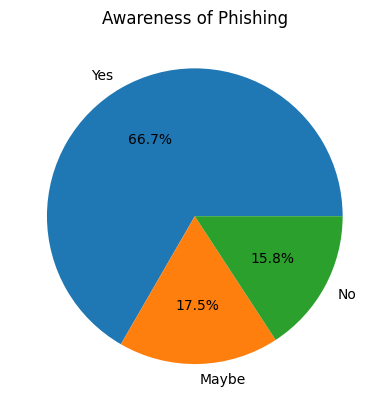

In [9]:
phishing_counts = df["Heard_Phishing"].value_counts()
print(phishing_counts)

phishing_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Awareness of Phishing")
plt.ylabel("")
plt.show()

count    57.000000
mean      3.228070
std       1.018008
min       1.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: Cybersecurity_Knowledge, dtype: float64


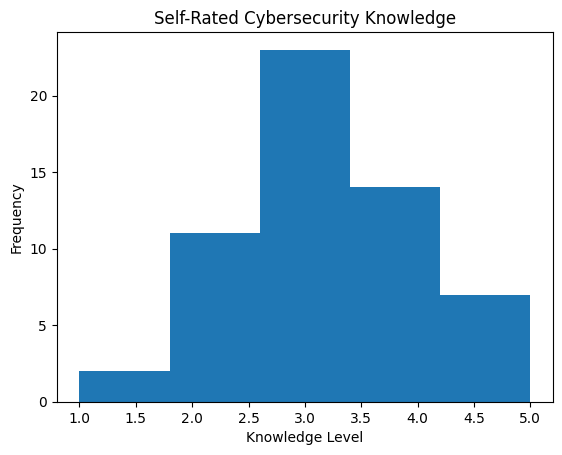

In [10]:
df["Cybersecurity_Knowledge"] = pd.to_numeric(df["Cybersecurity_Knowledge"], errors="coerce")

print(df["Cybersecurity_Knowledge"].describe())

df["Cybersecurity_Knowledge"].plot(kind="hist", bins=5)
plt.title("Self-Rated Cybersecurity Knowledge")
plt.xlabel("Knowledge Level")
plt.ylabel("Frequency")
plt.show()

Aware_AI_Phishing
Yes       38
May be    15
No         4
Name: count, dtype: int64


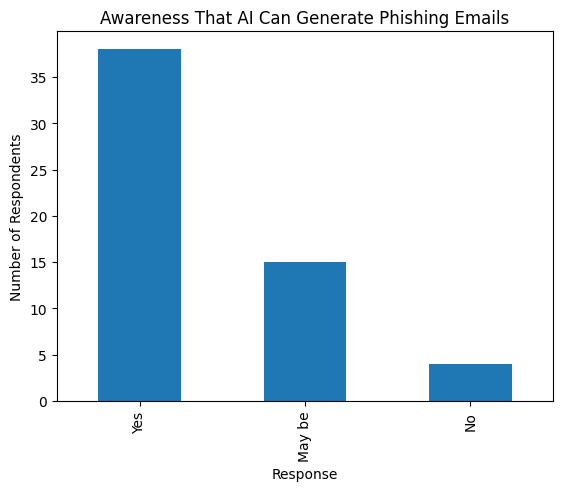

In [11]:
ai_awareness_counts = df["Aware_AI_Phishing"].value_counts()
print(ai_awareness_counts)

ai_awareness_counts.plot(kind="bar")
plt.title("Awareness That AI Can Generate Phishing Emails")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.show()

count    52.000000
mean      2.903846
std       1.124759
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: Familiar_AI_Phishing, dtype: float64


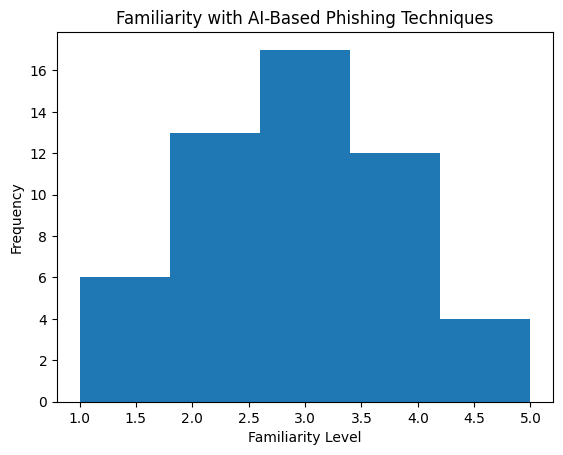

In [12]:
df["Familiar_AI_Phishing"] = pd.to_numeric(df["Familiar_AI_Phishing"], errors="coerce")

print(df["Familiar_AI_Phishing"].describe())

df["Familiar_AI_Phishing"].plot(kind="hist", bins=5)
plt.title("Familiarity with AI-Based Phishing Techniques")
plt.xlabel("Familiarity Level")
plt.ylabel("Frequency")
plt.show()

Reuse_Passwords
Yes    47
No     10
Name: count, dtype: int64


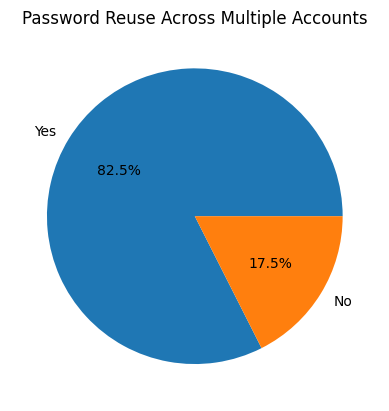

In [13]:
password_counts = df["Reuse_Passwords"].value_counts()
print(password_counts)

password_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Password Reuse Across Multiple Accounts")
plt.ylabel("")
plt.show()

Use_2FA
Sometimes    41
Always       14
Never         2
Name: count, dtype: int64


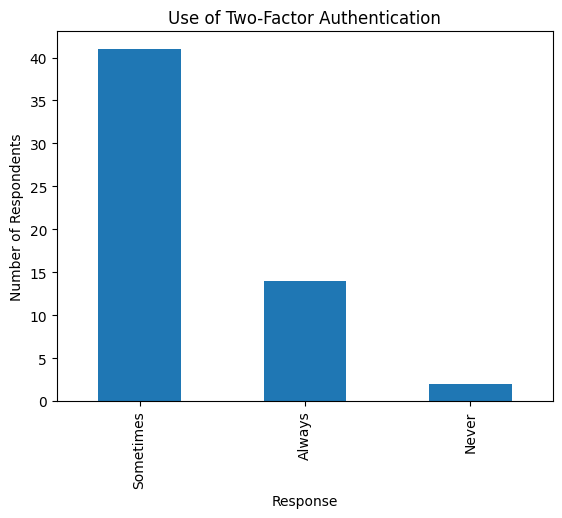

In [14]:
twofa_counts = df["Use_2FA"].value_counts()
print(twofa_counts)

twofa_counts.plot(kind="bar")
plt.title("Use of Two-Factor Authentication")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.show()

Check_URLs
Sometimes       18
Often           12
Always          12
Occasionally    11
Never            4
Name: count, dtype: int64


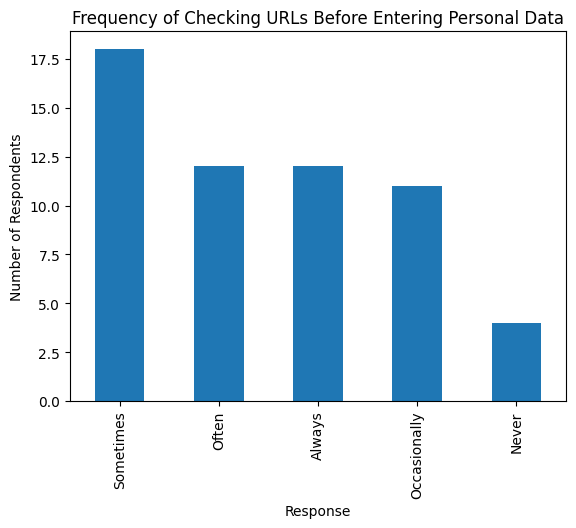

In [15]:
url_counts = df["Check_URLs"].value_counts()
print(url_counts)

url_counts.plot(kind="bar")
plt.title("Frequency of Checking URLs Before Entering Personal Data")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.show()

Email_Scenario_Response
Check the sender’s email address and website URL before taking action    30
Ignore the email                                                         22
Contact the official service provider through a trusted source            5
Name: count, dtype: int64


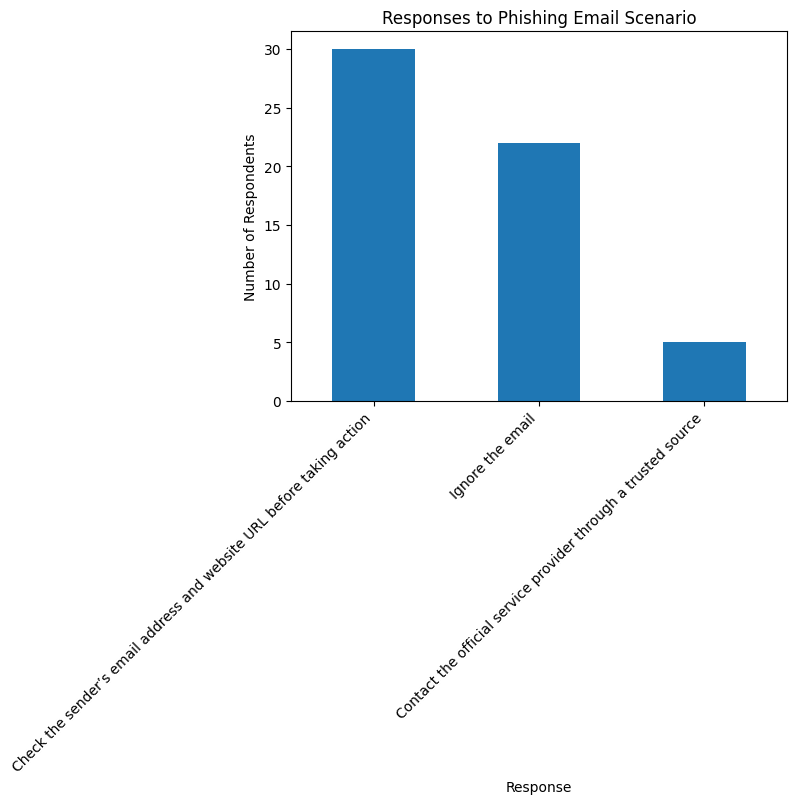

In [16]:
email_scenario_counts = df["Email_Scenario_Response"].value_counts()
print(email_scenario_counts)

email_scenario_counts.plot(kind="bar")
plt.title("Responses to Phishing Email Scenario")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.show()

In [17]:
correct_q12 = [
    "Check the sender’s email address and website URL before taking action",
    "Contact the official service provider through a trusted source"
]

df["Q12_Correct"] = df["Email_Scenario_Response"].isin(correct_q12).astype(int)

print(df["Q12_Correct"].value_counts())
print("Q12 Detection Accuracy:", df["Q12_Correct"].mean() * 100, "%")

Q12_Correct
1    35
0    22
Name: count, dtype: int64
Q12 Detection Accuracy: 61.40350877192983 %


AI_Video_Call_Experience
No       41
Yes      12
Maybe     2
Name: count, dtype: int64


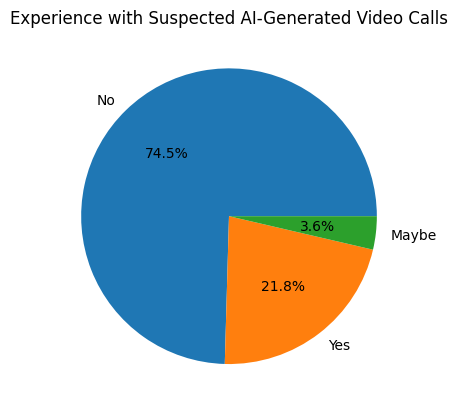

In [18]:
video_counts = df["AI_Video_Call_Experience"].value_counts()
print(video_counts)

video_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Experience with Suspected AI-Generated Video Calls")
plt.ylabel("")
plt.show()

Deepfake_Detection_Confidence
Neutral               21
Confident             17
Slightly Confident     9
Not Confident          4
Very  Confident        4
Name: count, dtype: int64


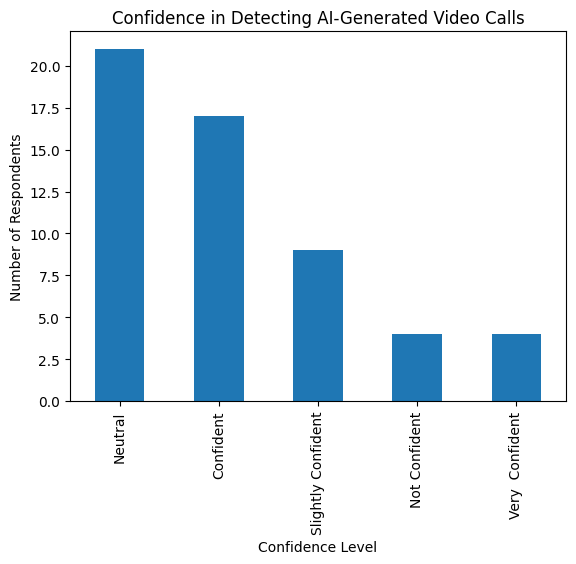

In [19]:
deepfake_counts = df["Deepfake_Detection_Confidence"].value_counts()
print(deepfake_counts)

deepfake_counts.plot(kind="bar")
plt.title("Confidence in Detecting AI-Generated Video Calls")
plt.xlabel("Confidence Level")
plt.ylabel("Number of Respondents")
plt.show()

OTP_Message_Response
Verify the request by contacting the person through another method (call/face-to-face)    31
Ignore the message                                                                        16
Report the message as suspicious                                                          10
Name: count, dtype: int64


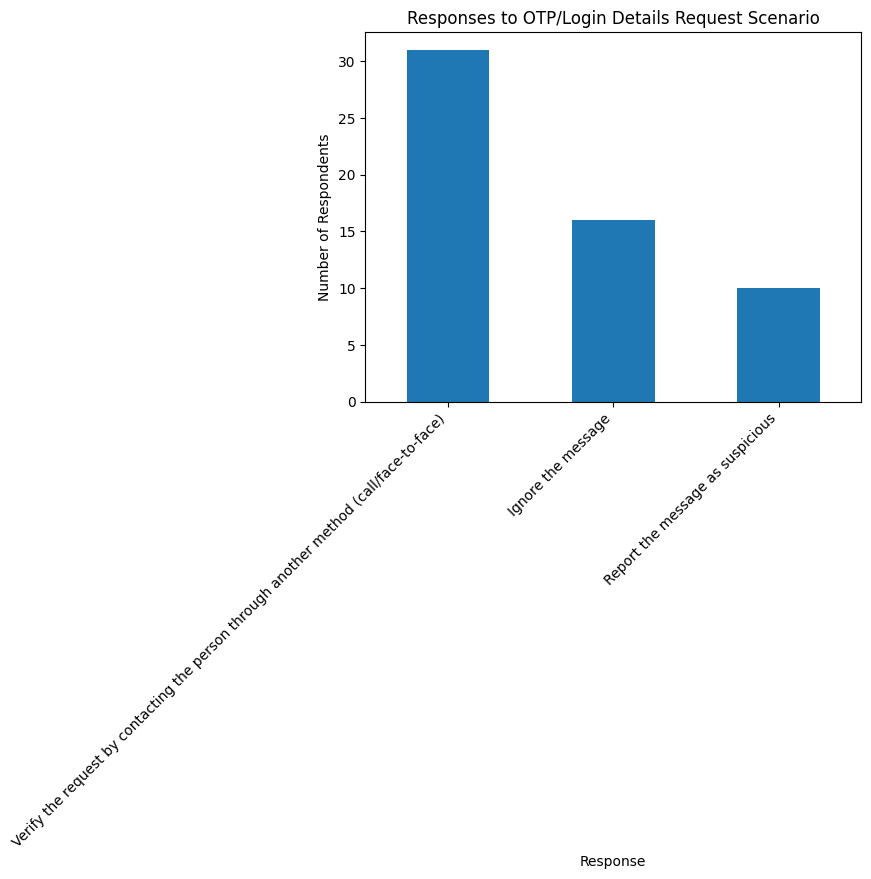

In [20]:
otp_counts = df["OTP_Message_Response"].value_counts()
print(otp_counts)

otp_counts.plot(kind="bar")
plt.title("Responses to OTP/Login Details Request Scenario")
plt.xlabel("Response")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
correct_q15 = [
    "Verify the request by contacting the person through another method (call/face-to-face)",
    "Report the message as suspicious"
]

df["Q15_Correct"] = df["OTP_Message_Response"].isin(correct_q15).astype(int)

print(df["Q15_Correct"].value_counts())
print("Q15 Detection Accuracy:", df["Q15_Correct"].mean() * 100, "%")

Q15_Correct
1    41
0    16
Name: count, dtype: int64
Q15 Detection Accuracy: 71.9298245614035 %


Clicked_Suspicious_Link
Maybe    26
Yes      17
No       14
Name: count, dtype: int64


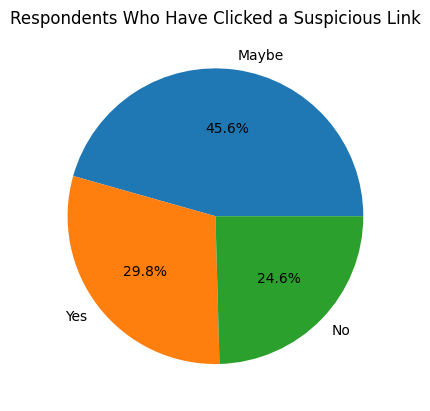

In [22]:
clicked_counts = df["Clicked_Suspicious_Link"].value_counts()
print(clicked_counts)

clicked_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Respondents Who Have Clicked a Suspicious Link")
plt.ylabel("")
plt.show()

Shared_Info_Unsecured_Website
Maybe    26
No       24
Yes       7
Name: count, dtype: int64


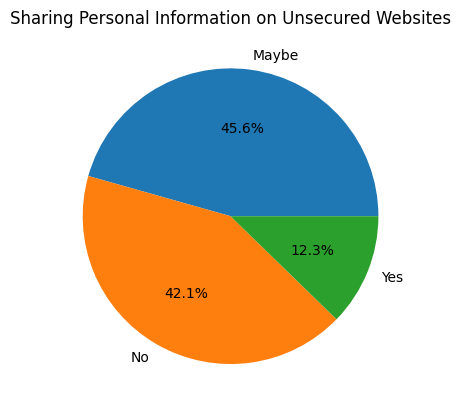

In [23]:
shared_counts = df["Shared_Info_Unsecured_Website"].value_counts()
print(shared_counts)

shared_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Sharing Personal Information on Unsecured Websites")
plt.ylabel("")
plt.show()

Learning_Preference
Social media          21
University courses    18
Online tutorials      17
Friends/Peers          1
Name: count, dtype: int64


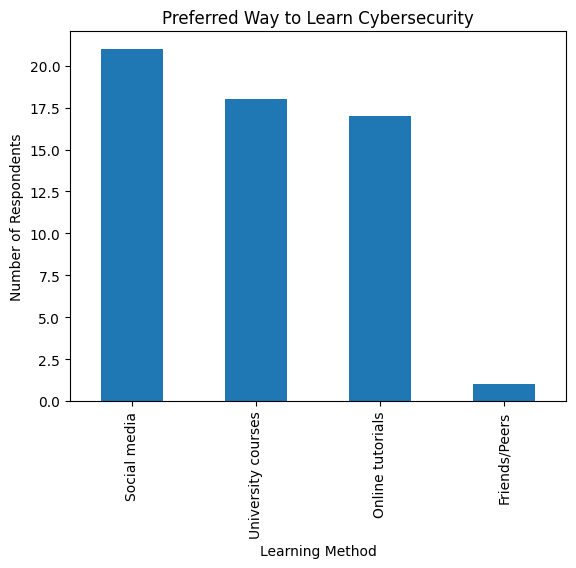

In [24]:
learning_counts = df["Learning_Preference"].value_counts()
print(learning_counts)

learning_counts.plot(kind="bar")
plt.title("Preferred Way to Learn Cybersecurity")
plt.xlabel("Learning Method")
plt.ylabel("Number of Respondents")
plt.show()

Hands_On_Training
Yes      45
Maybe     9
No        1
Name: count, dtype: int64


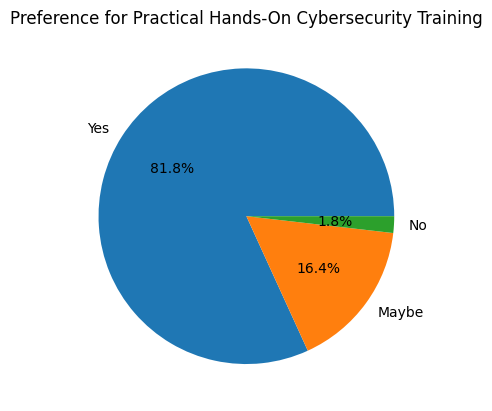

In [25]:
training_counts = df["Hands_On_Training"].value_counts()
print(training_counts)

training_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Preference for Practical Hands-On Cybersecurity Training")
plt.ylabel("")
plt.show()

In [26]:
# Table 1: Summary of Survey Responses and Dataset Characteristics

import pandas as pd

# Total responses
total_responses = len(df)

# Missing values
missing_values = df.isnull().sum().sum()

# Duplicate responses
duplicate_responses = df.duplicated().sum()

# Valid responses
valid_responses = total_responses - duplicate_responses

# Number of questions (excluding timestamp)
total_questions = len(df.columns) - 1

# Create summary table
summary_table = pd.DataFrame({
    "Dataset Characteristic": [
        "Total Responses Collected",
        "Valid Responses",
        "Duplicate Responses",
        "Missing Values",
        "Total Survey Questions"
    ],
    "Value": [
        total_responses,
        valid_responses,
        duplicate_responses,
        missing_values,
        total_questions
    ]
})

# Display table
print("\nTable 1: Summary of Survey Responses and Dataset Characteristics\n")
print(summary_table)



Table 1: Summary of Survey Responses and Dataset Characteristics

      Dataset Characteristic  Value
0  Total Responses Collected     57
1            Valid Responses     57
2        Duplicate Responses      0
3             Missing Values     11
4     Total Survey Questions     21


In [27]:
# Table 2: Phishing Detection Accuracy Results

import pandas as pd

# Correct answers for phishing scenarios
correct_q12 = [
    "Check the sender’s email address and website URL before taking action",
    "Contact the official service provider through a trusted source"
]

correct_q15 = [
    "Verify the request by contacting the person through another method (call/face-to-face)",
    "Report the message as suspicious"
]

# Creating correctness columns
df["Q12_Correct"] = df["Email_Scenario_Response"].isin(correct_q12)
df["Q15_Correct"] = df["OTP_Message_Response"].isin(correct_q15)

# Calculating accuracy percentages
q12_correct = df["Q12_Correct"].sum()
q12_total = len(df)
q12_accuracy = round((q12_correct / q12_total) * 100, 2)

q15_correct = df["Q15_Correct"].sum()
q15_total = len(df)
q15_accuracy = round((q15_correct / q15_total) * 100, 2)

# Overall accuracy
overall_correct = q12_correct + q15_correct
overall_total = q12_total + q15_total
overall_accuracy = round((overall_correct / overall_total) * 100, 2)

# Creating table
phishing_accuracy_table = pd.DataFrame({
    "Scenario": [
        "Email-Based Phishing Scenario (Q12)",
        "OTP Credential Theft Scenario (Q15)",
        "Overall Detection Accuracy"
    ],
    "Correct Responses": [
        q12_correct,
        q15_correct,
        overall_correct
    ],
    "Total Responses": [
        q12_total,
        q15_total,
        overall_total
    ],
    "Accuracy Percentage": [
        f"{q12_accuracy}%",
        f"{q15_accuracy}%",
        f"{overall_accuracy}%"
    ]
})

# Display table
print("\nTable 2: Phishing Detection Accuracy Results\n")
print(phishing_accuracy_table)




Table 2: Phishing Detection Accuracy Results

                              Scenario  Correct Responses  Total Responses  \
0  Email-Based Phishing Scenario (Q12)                 35               57   
1  OTP Credential Theft Scenario (Q15)                 41               57   
2           Overall Detection Accuracy                 76              114   

  Accuracy Percentage  
0               61.4%  
1              71.93%  
2              66.67%  


In [28]:
# Table 3: Cross-Tabulation Between Awareness Level and Risky Online Behaviour

import pandas as pd

# Converting awareness-related values to numeric
df["Cybersecurity_Knowledge"] = pd.to_numeric(df["Cybersecurity_Knowledge"], errors="coerce")
df["Familiar_AI_Phishing"] = pd.to_numeric(df["Familiar_AI_Phishing"], errors="coerce")

# Encode phishing awareness
df["Heard_Phishing_Score"] = df["Heard_Phishing"].map({
    "Yes": 1,
    "Maybe": 0.5,
    "May be": 0.5,
    "No": 0
})

df["Aware_AI_Phishing_Score"] = df["Aware_AI_Phishing"].map({
    "Yes": 1,
    "Maybe": 0.5,
    "May be": 0.5,
    "No": 0
})

# Create awareness score
df["Awareness_Score"] = (
    df["Heard_Phishing_Score"] +
    df["Aware_AI_Phishing_Score"] +
    df["Cybersecurity_Knowledge"] +
    df["Familiar_AI_Phishing"]
)

# Categorise awareness level
df["Awareness_Level"] = pd.cut(
    df["Awareness_Score"],
    bins=[0, 4, 6, 8],
    labels=["Low", "Moderate", "High"],
    include_lowest=True
)

# Encode risky online behaviour
df["Password_Risk"] = df["Reuse_Passwords"].map({
    "Yes": 1,
    "No": 0
})

df["TwoFA_Risk"] = df["Use_2FA"].map({
    "Always": 0,
    "Sometimes": 0.5,
    "Never": 1
})

df["URL_Risk"] = df["Check_URLs"].map({
    "Always": 0,
    "Often": 0.25,
    "Sometimes": 0.5,
    "Rarely": 0.75,
    "Never": 1
})

df["Clicked_Link_Risk"] = df["Clicked_Suspicious_Link"].map({
    "Yes": 1,
    "Not sure": 0.5,
    "No": 0
})

df["Unsecured_Website_Risk"] = df["Shared_Info_Unsecured_Website"].map({
    "Yes": 1,
    "Not sure": 0.5,
    "No": 0
})

# Creating total risk score
df["Risk_Score"] = (
    df["Password_Risk"] +
    df["TwoFA_Risk"] +
    df["URL_Risk"] +
    df["Clicked_Link_Risk"] +
    df["Unsecured_Website_Risk"]
)

# Categorise risky behaviour
df["Risk_Level"] = pd.cut(
    df["Risk_Score"],
    bins=[0, 1.5, 3, 5],
    labels=["Low Risk", "Moderate Risk", "High Risk"],
    include_lowest=True
)

# Create cross-tabulation
table_5_3 = pd.crosstab(
    df["Awareness_Level"],
    df["Risk_Level"],
    margins=True,
    margins_name="Total"
)

print("\nTable 3: Cross-Tabulation Between Awareness Level and Risky Online Behaviour\n")
print(table_5_3)




Table 3: Cross-Tabulation Between Awareness Level and Risky Online Behaviour

Risk_Level       Low Risk  Moderate Risk  High Risk  Total
Awareness_Level                                           
Low                     1              0          0      1
Moderate                0              0          1      1
High                    2              1          1      4
Total                   3              1          2      6


In [29]:
# Table 4: Chi-Square Analysis Between Awareness and Phishing Detection Capability

import pandas as pd
from scipy.stats import chi2_contingency

# Correct answers for phishing scenarios
correct_q12 = [
    "Check the sender’s email address and website URL before taking action",
    "Contact the official service provider through a trusted source"
]

correct_q15 = [
    "Verify the request by contacting the person through another method (call/face-to-face)",
    "Report the message as suspicious"
]

# Creating detection scores
df["Q12_Correct"] = df["Email_Scenario_Response"].isin(correct_q12).astype(int)
df["Q15_Correct"] = df["OTP_Message_Response"].isin(correct_q15).astype(int)

df["Detection_Score"] = df["Q12_Correct"] + df["Q15_Correct"]

# Categorise detection capability
df["Detection_Level"] = pd.cut(
    df["Detection_Score"],
    bins=[-1, 0, 1, 2],
    labels=["Low", "Moderate", "High"]
)

# Creating contingency table
contingency_table = pd.crosstab(
    df["Awareness_Level"],
    df["Detection_Level"]
)

# Run chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Creating final table
table_5_4 = pd.DataFrame({
    "Analysis": ["Awareness Level vs Phishing Detection Capability"],
    "Chi-Square Value": [round(chi2, 4)],
    "Degrees of Freedom": [dof],
    "p-value": [round(p_value, 4)],
    "Result": [
        "Significant relationship" if p_value < 0.05 else "No significant relationship"
    ]
})

print("\nTable 4: Chi-Square Analysis Between Awareness and Phishing Detection Capability\n")
print(table_5_4)




Table 4: Chi-Square Analysis Between Awareness and Phishing Detection Capability

                                           Analysis  Chi-Square Value  \
0  Awareness Level vs Phishing Detection Capability            3.4696   

   Degrees of Freedom  p-value                       Result  
0                   4   0.4825  No significant relationship  


In [30]:
# Create discipline group: Technical vs Non-Technical

def classify_discipline(field):
    if pd.isna(field):
        return "Unknown"
    field = str(field).lower()
    if "computer" in field or "it" in field or "engineering" in field:
        return "Technical"
    else:
        return "Non-Technical"

df["Discipline_Group"] = df["Field_of_Study"].apply(classify_discipline)

print(df["Discipline_Group"].value_counts())

Discipline_Group
Technical        36
Non-Technical    21
Name: count, dtype: int64


Awareness_Level   Low  Moderate  High
Discipline_Group                     
Non-Technical       2         8     5
Technical           1         6    10


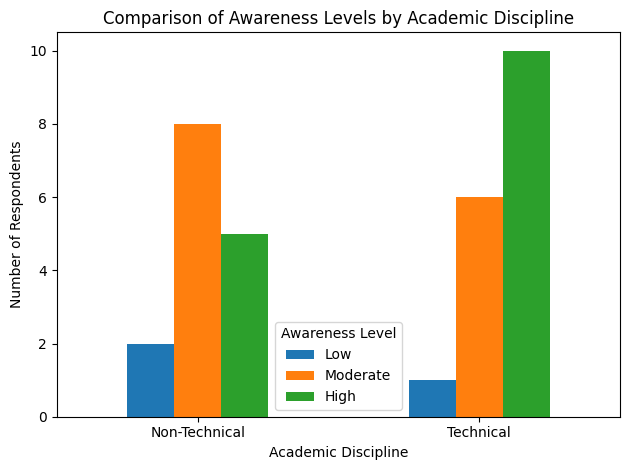

In [31]:
# Comparison of Awareness Levels by Academic Discipline

awareness_by_discipline = pd.crosstab(
    df["Discipline_Group"],
    df["Awareness_Level"]
)

print(awareness_by_discipline)

awareness_by_discipline.plot(kind="bar")

plt.title("Comparison of Awareness Levels by Academic Discipline")
plt.xlabel("Academic Discipline")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Awareness Level")
plt.tight_layout()
plt.show()

Discipline_Group
Non-Technical    50.000000
Technical        76.388889
Name: Detection_Accuracy_Percentage, dtype: float64


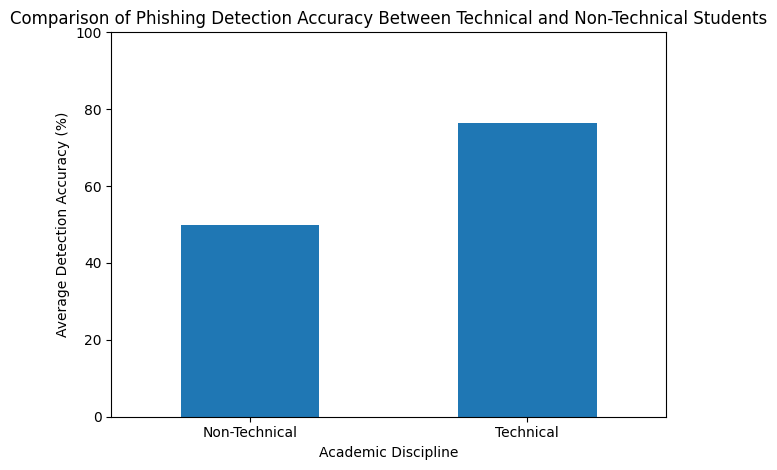

In [32]:
# Comparison of Phishing Detection Accuracy Between Technical and Non-Technical Students

# Detection score percentage for each respondent
df["Detection_Accuracy_Percentage"] = (df["Detection_Score"] / 2) * 100

detection_by_discipline = df.groupby("Discipline_Group")["Detection_Accuracy_Percentage"].mean()

print(detection_by_discipline)

detection_by_discipline.plot(kind="bar")

plt.title("Comparison of Phishing Detection Accuracy Between Technical and Non-Technical Students")
plt.xlabel("Academic Discipline")
plt.ylabel("Average Detection Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()